In [1]:
!pip install kaggle

In [8]:
kaggle = '/content/drive/MyDrive/STT NF/Semester 3/Machine Learning/Praktikum Mandiri/Praktikum Mandiri 13/kaggle.json'

In [10]:
!mkdir -p ~/.kaggle
!cp "{kaggle}" ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [11]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
  0% 0.00/66.7M [00:00<?, ?B/s]
100% 66.7M/66.7M [00:00<00:00, 1.55GB/s]


In [12]:
import os
from zipfile import ZipFile

file_name = 'handwritten-digits-0-9.zip'

extract_folder = 'dataset'
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)
    print('Done')

Done


In [13]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [14]:
len(data_0)

2236

In [15]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [18]:
dataset_path = '/content/dataset'
img_size = 64
data = []
labels = []

for angka in range(10):
    folder_angka = os.path.join(dataset_path, str(angka))
    # Cek isi folder
    if os.path.exists(folder_angka):
        print(f"Mengambil data angka {angka}...")
        for file_gambar in os.listdir(folder_angka):
            try:
                # Baca gambar & ubah jadi hitam putih (grayscale)
                img_path = os.path.join(folder_angka, file_gambar)
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                # Resize agar semua ukuran sama
                resized_array = cv2.resize(img_array, (img_size, img_size))

                data.append(resized_array)
                labels.append(angka)
            except Exception as e:
                pass

# 3. Ubah list menjadi Numpy Array & Normalisasi (0-1)
X = np.array(data) / 255.0
X = X.reshape(-1, img_size, img_size, 1) # Dimensi untuk Keras

# 4. Encoding Label (Sesuai konsep Neural Network)
# Mengubah angka "5" menjadi [0,0,0,0,0,1,0,0,0,0]
y = to_categorical(np.array(labels), num_classes=10)

# 5. Bagi Data Training & Testing (Sesuai Modul Hal 8)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nSelesai! Data siap.")
print(f"Jumlah Data Latih: {len(X_train)}")
print(f"Jumlah Data Uji: {len(X_test)}")

Mengambil data angka 0...
Mengambil data angka 1...
Mengambil data angka 2...
Mengambil data angka 3...
Mengambil data angka 4...
Mengambil data angka 5...
Mengambil data angka 6...
Mengambil data angka 7...
Mengambil data angka 8...
Mengambil data angka 9...

Selesai! Data siap.
Jumlah Data Latih: 17244
Jumlah Data Uji: 4311


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input

model = Sequential()

model.add(Input(shape=(img_size, img_size, 1)))
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,322 (2.03 MB)

 Trainable params: 533,322 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

Sedang memproses data (Inverting colors)...

Mulai Training Model...
Epoch 1/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3798 - loss: 1.8077 - val_accuracy: 0.6703 - val_loss: 1.1134
Epoch 2/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6583 - loss: 1.0838 - val_accuracy: 0.7614 - val_loss: 0.7847
Epoch 3/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7395 - loss: 0.8122 - val_accuracy: 0.8069 - val_loss: 0.6347
Epoch 4/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8027 - loss: 0.6357 - val_accuracy: 0.8136 - val_loss: 0.5890
Epoch 5/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8297 - loss: 0.5366 - val_accuracy: 0.8391 - val_loss: 0.5200
Epoch 6/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8468 - loss: 0.4749 - val_accuracy: 0.8452 - val_loss: 0.5034
Epoch 7/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8596 - loss: 0.4364 - val_accuracy: 0.8576 - val_loss: 0.4859
Epoch 8/50
432/432 ━━━━━━━━━━━━

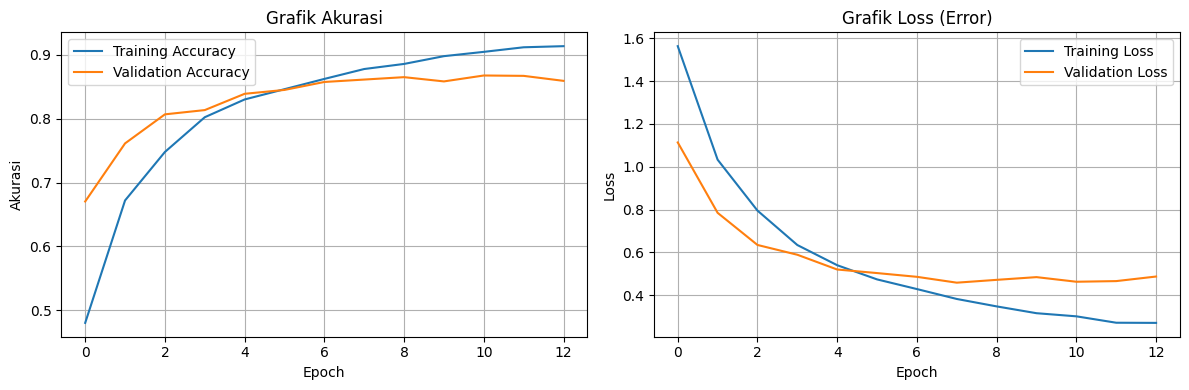

In [22]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

print("Sedang memproses data (Inverting colors)...")
X_inverted = 1.0 - X
y_integer = np.array(labels)


X_train, X_test, y_train, y_test = train_test_split(X_inverted, y_integer, test_size=0.2, random_state=42)


model = Sequential([
    Input(shape=(img_size, img_size, 1)), #img_size(64)
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])


model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


callback = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nMulai Training Model...")
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[callback],
                    verbose=1)


loss, accuracy = model.evaluate(X_test, y_test)
print(f"\n===== HASIL AKHIR =====")
print(f"Akurasi pada Data Test: {accuracy*100:.2f}%")


plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss (Error)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

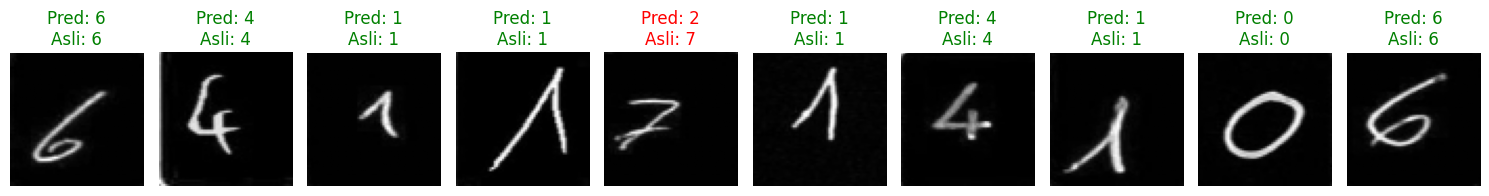

In [24]:
import numpy as np
import matplotlib.pyplot as plt

indices = np.random.randint(0, len(X_test), 10)

plt.figure(figsize=(15, 3))

for i, idx in enumerate(indices):
    plt.subplot(1, 10, i+1)

    # Menggunakan img_size yang benar untuk reshape gambar untuk tampilan
    img = X_test[idx].reshape(img_size, img_size)

    # Memastikan input untuk prediksi model juga menggunakan img_size yang benar
    img_input = X_test[idx].reshape(1, img_size, img_size, 1)
    prediksi = model.predict(img_input, verbose=0)
    label_prediksi = np.argmax(prediksi)
    label_asli = y_test[idx]

    plt.imshow(img, cmap='gray')

    warna = 'green' if label_prediksi == label_asli else 'red'

    plt.title(f"Pred: {label_prediksi}\nAsli: {label_asli}", color=warna)
    plt.axis('off')

plt.tight_layout()
plt.show()